In [1]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

from sklearn.preprocessing import MinMaxScaler , StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import tensorflow as tf 
import keras 
from keras.layers import Dense
from tensorflow.keras.layers import Dropout
from keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/d4rklucif3r/social-network-ads/Social_Network_Ads.csv


In [3]:
df = pd.read_csv('/kaggle/input/datasets/d4rklucif3r/social-network-ads/Social_Network_Ads.csv')

In [4]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


# Model EDA and pre processing 

In [5]:
df.head(10)

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
5,27,58000,0
6,27,84000,0
7,32,150000,1
8,25,33000,0
9,35,65000,0


In [6]:
df.shape

(400, 3)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [8]:
df.isna().sum()

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(33)

In [10]:
df.drop_duplicates(inplace= True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 367 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              367 non-null    int64
 1   EstimatedSalary  367 non-null    int64
 2   Purchased        367 non-null    int64
dtypes: int64(3)
memory usage: 11.5 KB


In [13]:
df.head(10)

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
5,27,58000,0
6,27,84000,0
7,32,150000,1
8,25,33000,0
9,35,65000,0


In [14]:
df['Purchased'].value_counts()

Purchased
0    229
1    138
Name: count, dtype: int64

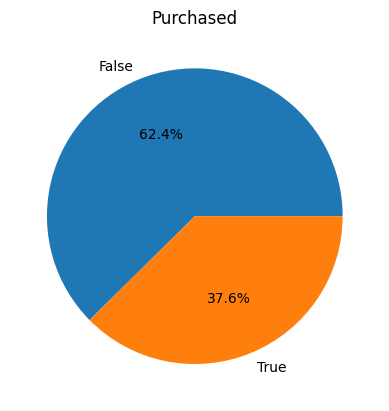

In [15]:
labels = 'False','True'
plt.title('Purchased')
plt.pie(df['Purchased'].value_counts(),labels = labels
       ,autopct='%1.1f%%')
plt.show()

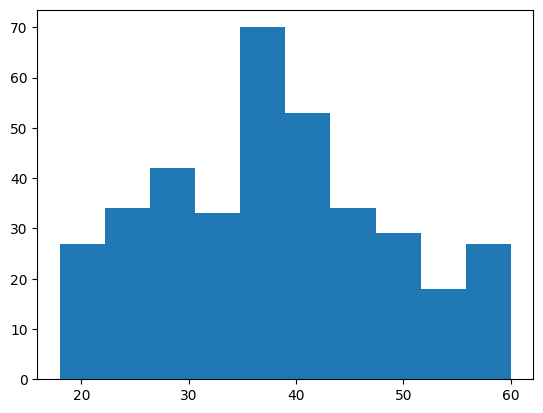

In [16]:
plt.hist(df['Age'])
plt.show()

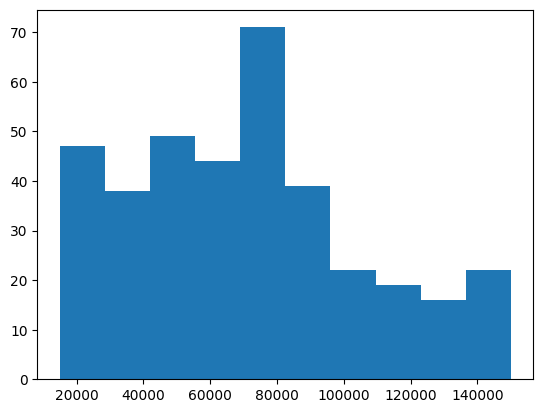

In [17]:
plt.hist(df['EstimatedSalary'])
plt.show()

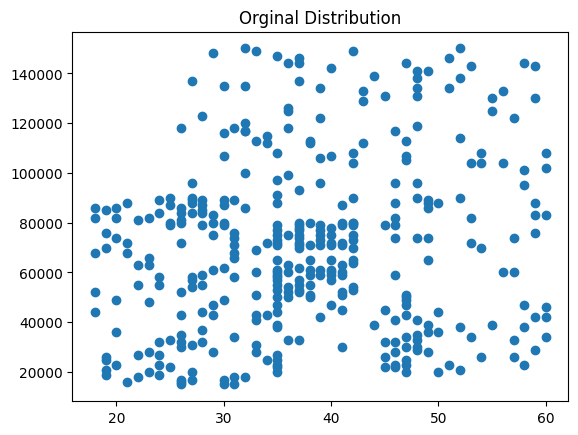

In [18]:
plt.title('Orginal Distribution')
plt.scatter(x= df['Age'],y= df['EstimatedSalary'])
plt.show()

In [19]:
# feature_scaling is required  is required

In [20]:
df.columns

Index(['Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [21]:
# data spliting in feature(X) and labels (y)
X = df.drop(columns = ['Purchased'])
y = df['Purchased']

In [22]:
print("Shapes\nX : " , X.shape)
print("y : " , y.shape)

Shapes
X :  (367, 2)
y :  (367,)


In [23]:
# using StandardScaler 
standard = StandardScaler()
X_standard = pd.DataFrame(standard.fit_transform(X),columns= X.columns)
X_standard.head(10)

,Age,EstimatedSalary
0,-1.755169,-1.489408
1,-0.255190,-1.460610
2,-1.098928,-0.798259
3,-1.005180,-0.395088
4,-1.755169,0.152072
5,-1.005180,-0.366290
6,-1.005180,0.382455
7,-0.536436,2.283115
8,-1.192677,-1.086238
9,-0.255190,-0.164705


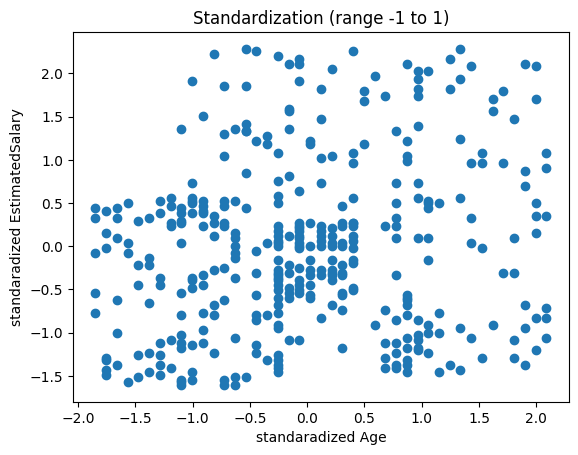

In [24]:
plt.title('Standardization (range -1 to 1)')
plt.xlabel('standaradized Age')
plt.ylabel('standaradized EstimatedSalary')
plt.scatter(x= X_standard['Age'],y= X_standard['EstimatedSalary'])
plt.show()

In [25]:
# using MinMaxScaler 
normalize = MinMaxScaler()
X_normalized = pd.DataFrame(normalize.fit_transform(X),columns=X.columns)
X_normalized.head(10)

,Age,EstimatedSalary
0,0.023810,0.029630
1,0.404762,0.037037
2,0.190476,0.207407
3,0.214286,0.311111
4,0.023810,0.451852
5,0.214286,0.318519
6,0.214286,0.511111
7,0.333333,1.000000
8,0.166667,0.133333
9,0.404762,0.370370


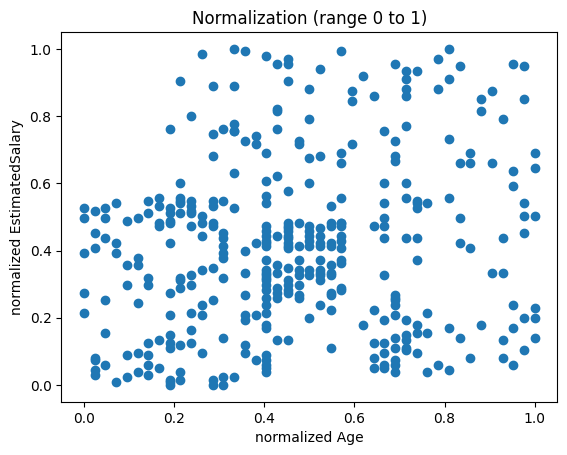

In [26]:
plt.title('Normalization (range 0 to 1)')
plt.xlabel('normalized Age')
plt.ylabel('normalized EstimatedSalary')
plt.scatter(x= X_normalized['Age'],y= X_normalized['EstimatedSalary'])
plt.show()

# Using Standrized Data for modeling

In [27]:
X_train,X_test,y_train,y_test = train_test_split(X_standard,y,test_size = 0.2,random_state=42)

In [28]:
print("Shapes\nX_train : " , X_train.shape)
print("y_train : " , y_train.shape)
print("X_test  : " , X_test.shape)
print("y_test  : " , X_test.shape)

Shapes
X_train :  (293, 2)
y_train :  (293,)
X_test  :  (74, 2)
y_test  :  (74, 2)


In [29]:
X_train

,Age,EstimatedSalary
342,2.088526,-0.711865
202,-0.255190,-0.366290
75,-0.911431,0.468848
84,-1.098928,0.296061
355,1.713531,-0.308695
...,...,...
71,-0.442688,1.217594
106,-0.067693,0.008082
270,0.307301,0.238465
348,0.401050,-0.510280


In [30]:
y_train

370    1
213    0
78     0
88     0
385    1
      ..
73     0
111    0
288    0
377    0
107    0
Name: Purchased, Length: 293, dtype: int64

# ANN Model Traning

In [31]:
model = Sequential()

model.add(Dense(8,activation='relu',input_dim= 2))
model.add(Dropout(0.5))

model.add(Dense(4,activation='relu'))
model.add(Dropout(0.25))        

model.add(Dense(2,activation='relu'))
# model.add(Dropout(0.5))   # first check only adding dropout in final layer

model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-07-08 10:07:47.711319: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [32]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73 (292.00 B)

 Trainable params: 73 (292.00 B)

 Non-trainable params: 0 (0.00 B)

In [33]:
# using earlystoping which helps us to give best results in required epochs 
#  and handles overfitting
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=10,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False
)

In [34]:
X_train.shape

(293, 2)

In [35]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])
# history = model.fit(X_train,y_train,epochs=100,validation_split=0.2,callbacks= callback)
history = model.fit(X_train,y_train,epochs=300,validation_split=0.2,callbacks= callback)

Epoch 1/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.5940 - loss: 0.6921 - val_accuracy: 0.6780 - val_loss: 0.6919
Epoch 2/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6239 - loss: 0.6911 - val_accuracy: 0.6780 - val_loss: 0.6909
Epoch 3/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6068 - loss: 0.6916 - val_accuracy: 0.6780 - val_loss: 0.6898
Epoch 4/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5897 - loss: 0.6916 - val_accuracy: 0.6780 - val_loss: 0.6888
Epoch 5/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6111 - loss: 0.6904 - val_accuracy: 0.6780 - val_loss: 0.6878
Epoch 6/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6026 - loss: 0.6900 - val_accuracy: 0.6780 - val_loss: 0.6869
Epoch 7/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6154 - loss: 0.6890 - val_accuracy: 0.6780 - val_loss: 0.6858
Epoch 8/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6197 - loss: 0.6883 - val_accuracy: 0.6780 - val_loss:

# Discription<br>
## 1. Gradient Descent
- on batch gradient descent (bach_size=293 as training set row = 293) the training accuracy was 0.91  (over fits)
- on stochastic gradient (batch_size=1) the the train accuracy increased to 0.91 to 0.92 (over fits)
- on mini batch gradient (batch_size=20) the training accuracy is increase to 91 to 0.93  (over fits)
- but the training accuracy remain same  0.88 hence over fit in SGD and BGD
- on default batch_size it give good results and also genrealized

## 2. Early stoping ( callback) it is used to determine number of epochs and handle overfits
- early stoping stop the model after the 70 epochs with training accuraccy 0.91 and v 0.89

## 3. Droput 
- when i adjust the Dropout p=0.5 in last hidden layer the loss = 0.45 and val_loss =  0.48  and train accuracy = 0.86 and val_accuracy = 0.91
- when i adjust the Dropout p=0.5 and 0.25 for first and second hidden layer respectively the final results : train accuracy: 0.8077,val_accuracy: 0.9153,loss: 0.5228,val_loss: 0.4746 and the it run for 100 epochs doenst stop by early stoping(no overfit seen by model).
- when i adjuct Dropout p=0.5  at first  hidden layer results: accuracy: 0.8547 - loss: 0.3582 - val_accuracy: 0.8644 - val_loss: 0.3256 and the early stoping doesnt trigred with 200 epochs

# Conclusion:
1. batch_size=default (mini-batch)
2. EarlyStopping reduced unnecessary computation and helped limit overfitting.
3. the dropout p1=0.5 and p2 =0.25 give me best results

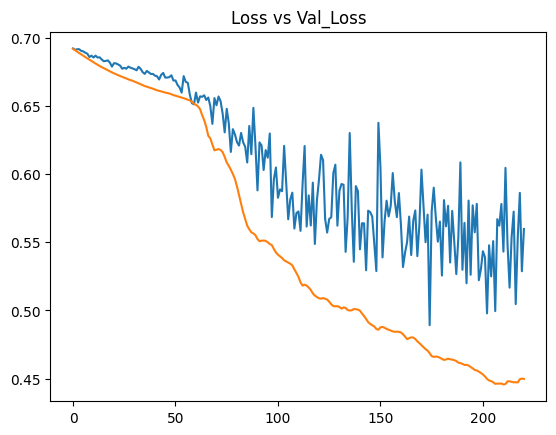

In [36]:
plt.title('Loss vs Val_Loss')
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

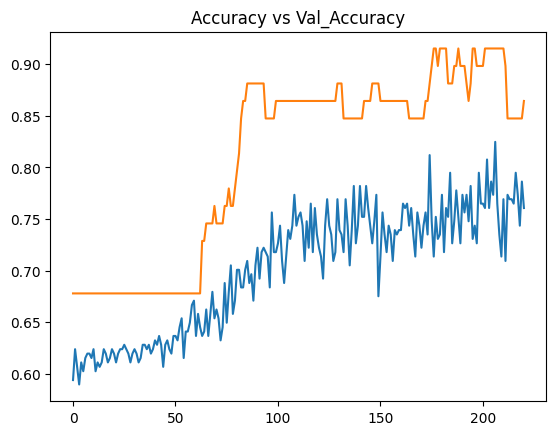

In [37]:
plt.title("Accuracy vs Val_Accuracy")
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


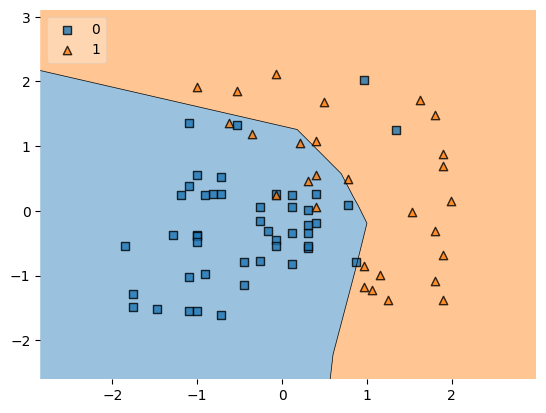

In [38]:


plot_decision_regions(np.array(X_test), np.array(y_test), clf = model, legend=2)
plt.show()

# ANN Model Testing

In [39]:
y_log = model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [40]:
y_log[:5]

array([[0.8485182 ],
       [0.31407514],
       [0.29824042],
       [0.73441035],
       [0.4749409 ]], dtype=float32)

In [41]:
y_pred = np.where(y_log > 0.5, 1, 0)

In [42]:
y_pred[:5]

array([[1],
       [0],
       [0],
       [1],
       [0]])

In [43]:
accuracy_score(y_test,y_pred)

0.8783783783783784